<a href="https://colab.research.google.com/github/Felixvoz/shines-ouessant-gboml/blob/main/Shines_Ouessant_GBOML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ===============================
# SHINES – Ouessant Energy Model
# Installation de l'environnement
# ===============================

# Installer GBOML
!pip install gboml

# Installer le solveur HiGHS
!pip install highspy

# Librairies utiles pour les données et graphiques
!pip install pandas matplotlib numpy openpyxl

print("Installation terminée")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.9/141.9 kB 5.0 MB/s eta 0:00:00
Installation terminée


In [3]:
# ===============================
# Import des librairies
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import json

# Vérifier la version de GBOML
!python -m gboml --version

# Afficher le dossier de travail
print("Dossier de travail :", os.getcwd())

# Afficher les fichiers présents
print("Fichiers dans le dossier :")
print(os.listdir())

/usr/bin/python3: No module named gboml.__main__; 'gboml' is a package and cannot be directly executed
Dossier de travail : /content
Fichiers dans le dossier :
['.config', 'sample_data']


In [5]:
# ===============================
# Upload données SOLAIRES
# ===============================

from google.colab import files
import os

print("Upload du fichier solaire (pure_solar_pv.csv)")

uploaded = files.upload()

for filename in uploaded.keys():
    os.rename(filename, os.path.join("data", "solar.csv"))

print("Fichier solaire enregistré dans data/solar.csv")

Upload du fichier solaire (pure_solar_pv.csv)


Saving pure_solar_pv.csv.csv to pure_solar_pv.csv.csv
Fichier solaire enregistré dans data/solar.csv


In [6]:
# ===============================
# Upload données EOLIEN
# ===============================

from google.colab import files
import os

print("Upload du fichier éolien (pure_wind_offshore.csv)")

uploaded = files.upload()

for filename in uploaded.keys():
    os.rename(filename, os.path.join("data", "wind.csv"))

print("Fichier éolien enregistré dans data/wind.csv")

Upload du fichier éolien (pure_wind_offshore.csv)


Saving pure_wind_offshore.csv.csv to pure_wind_offshore.csv.csv
Fichier éolien enregistré dans data/wind.csv


In [7]:
# ===============================
# Upload données HYDROLIEN
# ===============================

from google.colab import files
import os

print("Upload du fichier hydrolien Excel")

uploaded = files.upload()

for filename in uploaded.keys():
    os.rename(filename, os.path.join("data", "hydro.xlsx"))

print("Fichier hydrolien enregistré dans data/hydro.xlsx")

Upload du fichier hydrolien Excel


Saving Shines - Fromveur Etudes.xlsx to Shines - Fromveur Etudes.xlsx
Fichier hydrolien enregistré dans data/hydro.xlsx


In [10]:
# ===============================
# Lecture correcte des données
# ===============================

# Lire les fichiers Renewable Ninja
solar = pd.read_csv("data/solar.csv", skiprows=3)
wind = pd.read_csv("data/wind.csv", skiprows=3)

print("Solar shape :", solar.shape)
print("Wind shape :", wind.shape)

print("\nColonnes solar :")
print(solar.columns)

print("\nColonnes wind :")
print(wind.columns)

print("\nAperçu solar :")
display(solar.head())

print("\nAperçu wind :")
display(wind.head())

Solar shape : (8760, 3)
Wind shape : (8760, 3)

Colonnes solar :
Index(['time', 'local_time', 'electricity'], dtype='object')

Colonnes wind :
Index(['time', 'local_time', 'electricity'], dtype='object')

Aperçu solar :


,time,local_time,electricity
0,2019-01-01 00:00,2019-01-01 01:00,0.0
1,2019-01-01 01:00,2019-01-01 02:00,0.0
2,2019-01-01 02:00,2019-01-01 03:00,0.0
3,2019-01-01 03:00,2019-01-01 04:00,0.0
4,2019-01-01 04:00,2019-01-01 05:00,0.0



Aperçu wind :


,time,local_time,electricity
0,2019-01-01 00:00,2019-01-01 01:00,0.077
1,2019-01-01 01:00,2019-01-01 02:00,0.073
2,2019-01-01 02:00,2019-01-01 03:00,0.067
3,2019-01-01 03:00,2019-01-01 04:00,0.057
4,2019-01-01 04:00,2019-01-01 05:00,0.049


Statistiques solaire :
count    8760.000000
mean        0.151071
std         0.233193
min         0.000000
25%         0.000000
50%         0.000000
75%         0.239000
max         0.853000
Name: solar_cf, dtype: float64

Statistiques éolien :
count    8760.000000
mean        0.585940
std         0.305809
min         0.001000
25%         0.332000
50%         0.615000
75%         0.879000
max         0.991000
Name: wind_cf, dtype: float64


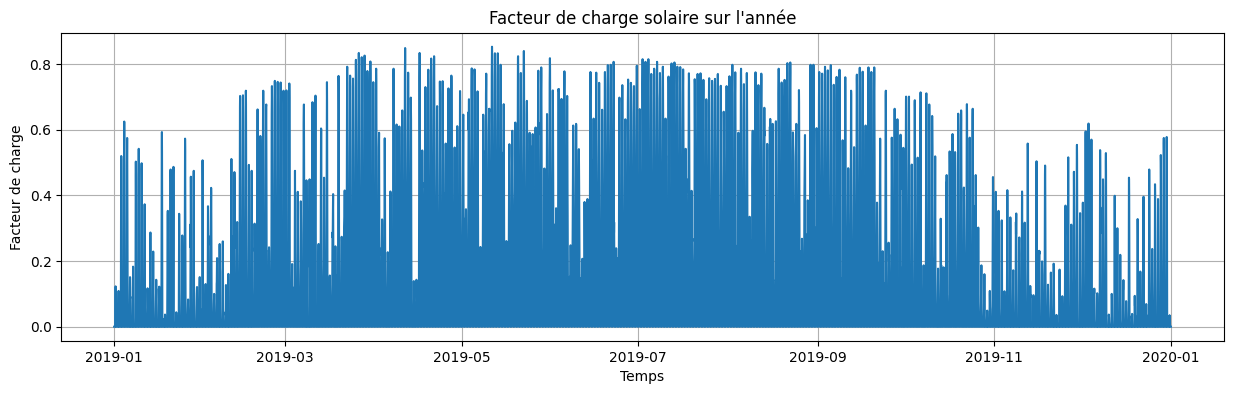

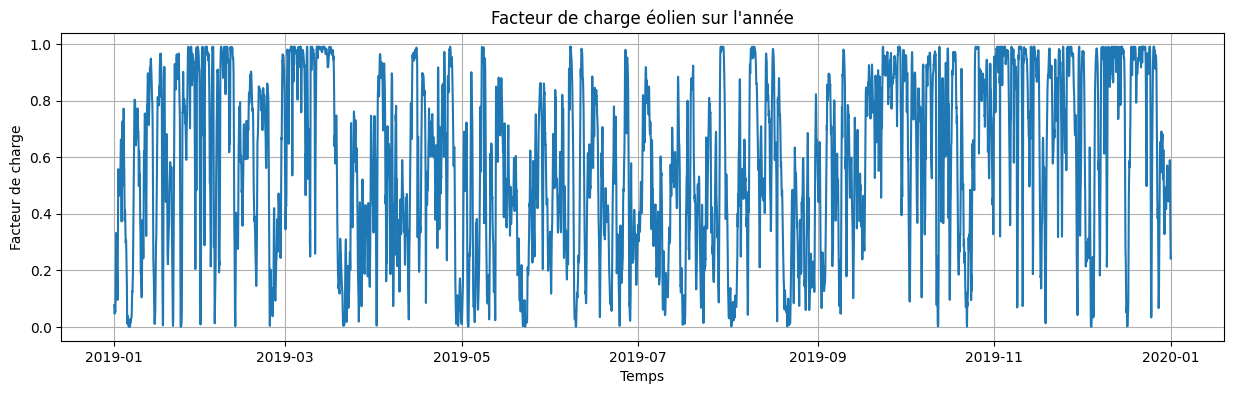

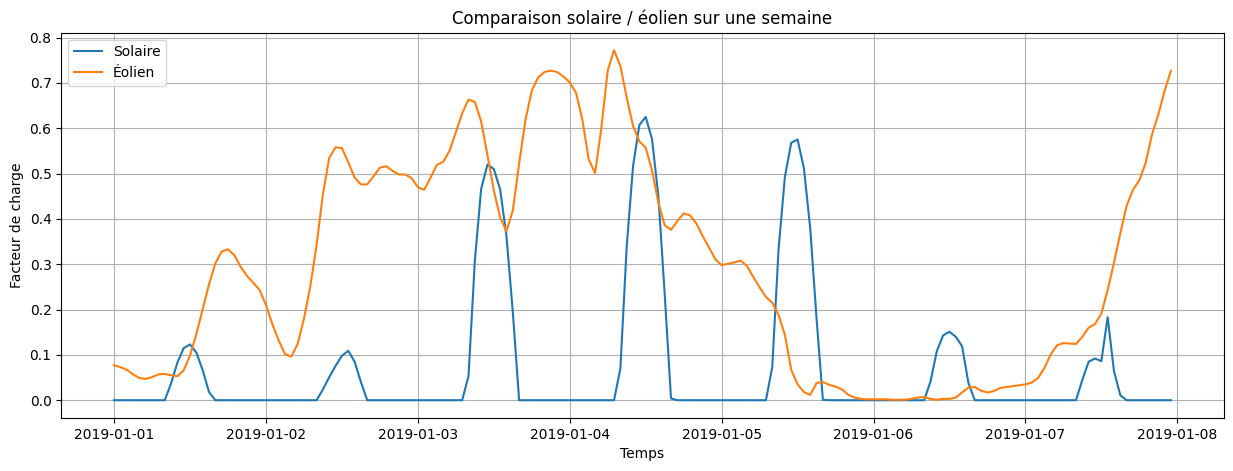

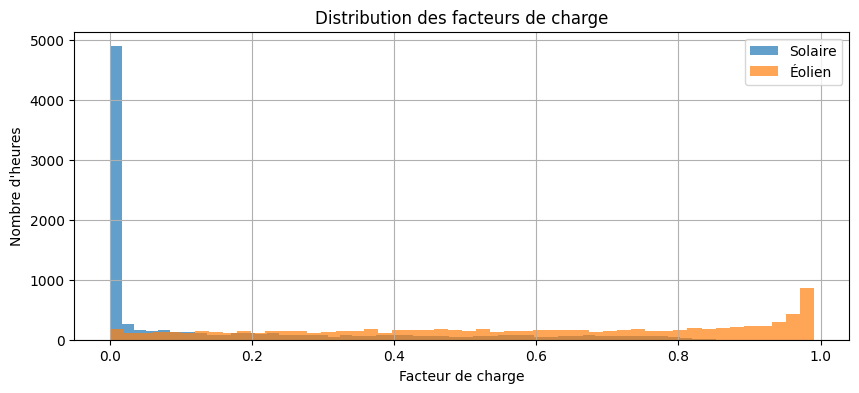

In [11]:
# ===============================
# Préparation et graphiques
# ===============================

# Conversion de la colonne temps
solar["time"] = pd.to_datetime(solar["time"])
wind["time"] = pd.to_datetime(wind["time"])

# Renommer pour être plus clair
solar = solar.rename(columns={"electricity": "solar_cf"})
wind = wind.rename(columns={"electricity": "wind_cf"})

# Vérification rapide
print("Statistiques solaire :")
print(solar["solar_cf"].describe())

print("\nStatistiques éolien :")
print(wind["wind_cf"].describe())

# Graphique 1 : année complète solaire
plt.figure(figsize=(15,4))
plt.plot(solar["time"], solar["solar_cf"])
plt.title("Facteur de charge solaire sur l'année")
plt.xlabel("Temps")
plt.ylabel("Facteur de charge")
plt.grid(True)
plt.show()

# Graphique 2 : année complète éolien
plt.figure(figsize=(15,4))
plt.plot(wind["time"], wind["wind_cf"])
plt.title("Facteur de charge éolien sur l'année")
plt.xlabel("Temps")
plt.ylabel("Facteur de charge")
plt.grid(True)
plt.show()

# Graphique 3 : comparaison sur une semaine
start = 0
end = 24 * 7

plt.figure(figsize=(15,5))
plt.plot(solar["time"].iloc[start:end], solar["solar_cf"].iloc[start:end], label="Solaire")
plt.plot(wind["time"].iloc[start:end], wind["wind_cf"].iloc[start:end], label="Éolien")
plt.title("Comparaison solaire / éolien sur une semaine")
plt.xlabel("Temps")
plt.ylabel("Facteur de charge")
plt.legend()
plt.grid(True)
plt.show()

# Graphique 4 : histogrammes
plt.figure(figsize=(10,4))
plt.hist(solar["solar_cf"], bins=50, alpha=0.7, label="Solaire")
plt.hist(wind["wind_cf"], bins=50, alpha=0.7, label="Éolien")
plt.title("Distribution des facteurs de charge")
plt.xlabel("Facteur de charge")
plt.ylabel("Nombre d'heures")
plt.legend()
plt.grid(True)
plt.show()

### Analyse du facteur de charge solaire

Ce graphique représente l'évolution du facteur de charge solaire sur une année complète, à partir des données horaires issues de Renewable Ninja.

Le facteur de charge traduit la production relative d'une installation photovoltaïque normalisée. On observe une forte intermittence journalière, avec une production nulle pendant la nuit, ainsi qu'une variation saisonnière marquée entre l'hiver et l'été.

Ces résultats montrent que le solaire peut contribuer au mix énergétique, mais qu'il ne peut pas, à lui seul, assurer l'équilibre entre production et consommation à chaque heure.

**Source des données :**
- Renewable Ninja
- Série temporelle horaire sur 8760 heures

**Hypothèses actuelles :**
- les données sont utilisées telles quelles comme profil de production normalisé
- aucune contrainte de surface ou de puissance installable n'est encore imposée à ce stade

**Améliorations futures :**
- intégrer une puissance photovoltaïque réellement installée
- tenir compte de contraintes physiques locales (surface disponible, orientation, ombrage)
- comparer plusieurs hypothèses technologiques

### Analyse du facteur de charge éolien

Ce graphique présente l'évolution du facteur de charge éolien sur une année complète à partir de données horaires issues de Renewable Ninja.

Contrairement au solaire, l'éolien présente une production potentielle à toute heure du jour et de la nuit. Le profil reste toutefois très variable selon les conditions météorologiques. Cette technologie semble plus régulière que le solaire, ce qui en fait un bon candidat pour compléter la production photovoltaïque.

**Source des données :**
- Renewable Ninja
- Série temporelle horaire sur 8760 heures

**Hypothèses actuelles :**
- le profil éolien est utilisé comme série normalisée
- aucune limite de puissance installable n'est encore appliquée
- le type exact d'éolienne n'est pas encore précisé dans cette phase exploratoire

**Améliorations futures :**
- intégrer une courbe de puissance réelle associée à une machine donnée
- considérer des contraintes techniques et économiques plus précises
- comparer plusieurs puissances installées possibles

### Comparaison solaire / éolien sur une semaine

Ce graphique compare les profils de production relatifs du solaire et de l'éolien sur une semaine représentative.

Le solaire suit une logique très marquée par l'alternance jour/nuit, tandis que l'éolien suit une dynamique différente, moins prévisible mais potentiellement disponible à tout moment. Cette comparaison met en évidence une certaine complémentarité entre les deux sources, ce qui justifie leur intégration conjointe dans un système multi-énergies.

**Intérêt pour le projet :**
- identifier la complémentarité temporelle entre les technologies
- montrer que plusieurs sources renouvelables sont nécessaires
- préparer l'intégration d'un stockage ou d'un groupe électrogène d'appoint

**Limites actuelles :**
- la semaine affichée n'est qu'un extrait de l'année
- la consommation réelle horaire n'est pas encore intégrée à ce stade
- aucune optimisation n'a encore été lancée dans ce graphique descriptif

### Distribution statistique des facteurs de charge

Cet histogramme montre la répartition des heures selon le niveau de facteur de charge pour le solaire et l'éolien.

On observe que le solaire présente un grand nombre d'heures à faible ou nulle production, ce qui est cohérent avec l'absence de production nocturne. L'éolien montre une distribution différente, avec davantage d'heures à production intermédiaire. Ce type d'analyse permet de mieux comprendre la variabilité intrinsèque de chaque ressource.

**Utilité de ce graphique :**
- caractériser statistiquement les ressources disponibles
- comparer la régularité relative des différentes technologies
- préparer le dimensionnement futur du stockage

**Améliorations futures :**
- ajouter l'hydrolien à cette comparaison
- comparer plusieurs sites ou plusieurs années météorologiques
- calculer des indicateurs complémentaires (moyenne, médiane, percentiles)

In [12]:
# ===============================
# Exploration du fichier hydrolien
# ===============================

# Ouvrir le fichier Excel
hydro_file = pd.ExcelFile("data/hydro.xlsx")

# Afficher les feuilles disponibles
print("Feuilles disponibles :")
print(hydro_file.sheet_names)

# Lire les premières lignes de chaque feuille
for sheet in hydro_file.sheet_names:
    print("\n" + "="*80)
    print(f"Feuille : {sheet}")
    df_sheet = pd.read_excel("data/hydro.xlsx", sheet_name=sheet)
    print("Dimensions :", df_sheet.shape)
    display(df_sheet.head(10))

Feuilles disponibles :
['Calcul puissance cinétique', 'Coefficient de marée', 'Etude du point -4,82 Lat 48,34', 'Données Prod Sabella DX']

Feuille : Calcul puissance cinétique
Dimensions : (17181, 18)


,Longitude,Lattitude,Vitesse moyenne zone morte (m/s),Vitesse moyenne eaux vives (m/s),Vc (m/s),Puissance cinétique (w),Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17
0,-4.82438,48.3393,0.865759,1.700307,1.616852,170049.173530,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Coefficient de marée,Densité de l'eau salée,Rayon du rotor,Surface du rotor
1,-5.06489,48.4299,0.714600,1.634945,1.542910,147769.693926,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90,1025,5,78.5
2,-5.07833,48.4138,0.935784,1.421089,1.372559,104029.492267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-4.79251,48.3415,0.518307,1.456539,1.362716,101807.395149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-5.06707,48.4837,0.592137,1.389750,1.309989,90441.210139,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,-4.96762,48.3872,0.653835,1.357591,1.287216,85805.940984,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,-4.99953,48.3948,0.677636,1.271472,1.212088,71641.765705,NaN,NaN,NaN,Voici la feuille calcul de puissance cinétique...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,-5.02010,48.4596,0.734877,1.254413,1.202459,69947.915676,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,-4.83597,48.3663,0.705878,1.240100,1.186677,67229.772573,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,-4.82043,48.3653,0.731306,1.237165,1.186580,67213.123646,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Feuille : Coefficient de marée
Dimensions : (102, 75)


,Unnamed: 0,2025,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 65,Unnamed: 66,Unnamed: 67,Unnamed: 68,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72,Unnamed: 73,Unnamed: 74
0,NaN,Janvier,NaN,NaN,NaN,Février,NaN,NaN,NaN,Mars,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Jour,Coef bas,Coef haut,Coef moy,Jour,Coef bas,Coef haut,Coef moy,Jour,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,1,80,81,80.5,1,99,98,98.5,1,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,2,82,83,82.5,2,96,93,94.5,2,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,3,82,81,81.5,3,89,84,86.5,3,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,4,80,78,79,4,78,71,74.5,4,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,5,75,72,73.5,5,64,57,60.5,5,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,6,68,64,66,6,50,46,48,6,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,7,61,58,59.5,7,43,NaN,43,7,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,8,55,NaN,55,8,43,46,44.5,8,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Feuille : Etude du point -4,82 Lat 48,34
Dimensions : (401, 45)


,Longitude,Lattitude,Vitesse moyenne zone morte (m/s),Vitesse moyenne eaux vives (m/s),Vc (m/s),Puissance cinétique (w),Energie annuel (kw/h),Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44
0,-4.82438,48.3393,0.865759,1.700307,1.700307,197763.233705,1.700307,NaN,NaN,NaN,...,Août,NaN,Septembre,NaN,Octobre,NaN,Novembre,NaN,Décembre,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Vitesse moyenne du jour,Energie produite journalière (kw/h),Vitesse moyenne du jour,Energie produite journalière (kw/h),Vitesse moyenne du jour,Energie produite journalière (kw/h),Vitesse moyenne du jour,Energie produite journalière (kw/h),Vitesse moyenne du jour,Energie produite journalière (kw/h)
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.857414,608.620231,0.565322,174.446829,0.515249,132.077038,0.915832,741.690289,1.132815,1403.625755
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.69885,329.553921,0.515249,132.077038,0.632086,243.839167,1.182887,1598.104195,1.333106,2287.540954
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.615395,225.028202,0.632086,243.839167,0.88245,663.507184,1.449943,2943.25106,1.525052,3424.748866
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.615395,225.028202,0.865759,626.565438,1.174542,1564.517569,1.666925,4472.218603,1.65858,4405.383721
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.715541,353.735024,1.124469,1372.832086,1.449943,2943.25106,1.825489,5873.710367,1.742034,5104.402739
7,Cette feuille à pour but de calculer l'énergi...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.88245,663.507184,1.383179,2555.111462,1.691962,4676.772201,1.883907,6455.850608,1.742034,5104.402739
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.082742,1225.602001,1.600161,3956.088951,1.867217,6285.774685,1.84218,6036.302847,1.675271,4539.726065
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.283033,2039.334462,1.767071,5327.661512,1.942326,7075.237213,1.708652,4816.549066,1.541743,3538.430656



Feuille : Données Prod Sabella DX
Dimensions : (57, 4)


,Vitesse de pales,Puissance produite D10,Puissance produite D12,Puissance produite D15
0,0.1,0.0,0.0,0.0
1,0.2,0.0,0.0,0.0
2,0.3,0.0,0.0,0.0
3,0.4,0.0,0.0,0.0
4,0.5,0.0,0.0,0.0
5,0.6,0.0,0.0,0.0
6,0.7,0.0,0.0,0.0
7,0.8,0.0,0.0,0.0
8,0.9,0.0,0.0,0.0
9,1,0.0,0.0,0.0


Dimensions brutes Sabella : (57, 4)


,Vitesse de pales,Puissance produite D10,Puissance produite D12,Puissance produite D15
47,4.8,1.1,1.5,2.5
48,4.9,1.1,1.5,2.5
49,5,1.1,1.5,2.5
50,5.1,1.1,1.5,2.5
51,5.2,1.1,1.5,2.5
52,5.3,1.1,1.5,2.5
53,5.4,1.1,1.5,2.5
54,5.5,1.1,1.5,2.5
55,NaN,NaN,NaN,NaN
56,Donnée issue de https://www.sabella.fr/fiche_i...,NaN,NaN,NaN


Dimensions nettoyées Sabella : (55, 4)


,Vitesse de pales,Puissance produite D10,Puissance produite D12,Puissance produite D15
0,0.1,0.000000,0.000000,0.000000
1,0.2,0.000000,0.000000,0.000000
2,0.3,0.000000,0.000000,0.000000
3,0.4,0.000000,0.000000,0.000000
4,0.5,0.000000,0.000000,0.000000
5,0.6,0.000000,0.000000,0.000000
6,0.7,0.000000,0.000000,0.000000
7,0.8,0.000000,0.000000,0.000000
8,0.9,0.000000,0.000000,0.000000
9,1.0,0.000000,0.000000,0.000000


,Vitesse de pales,Puissance produite D10,Puissance produite D12,Puissance produite D15
50,5.1,1.1,1.5,2.5
51,5.2,1.1,1.5,2.5
52,5.3,1.1,1.5,2.5
53,5.4,1.1,1.5,2.5
54,5.5,1.1,1.5,2.5


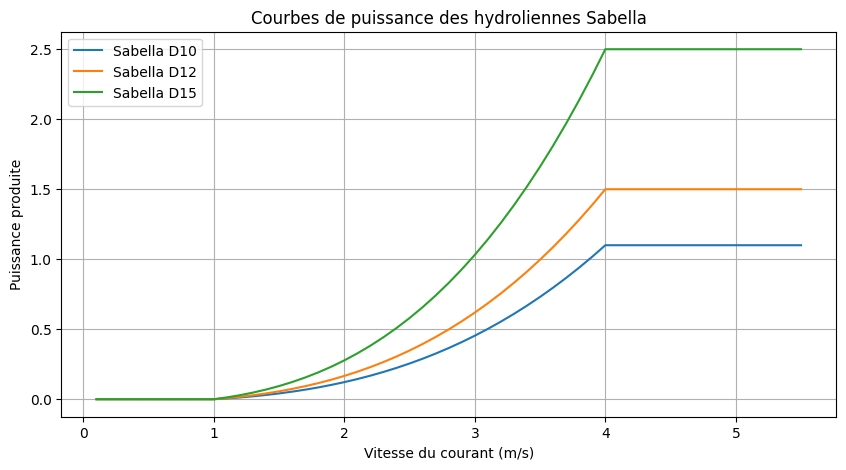

In [14]:
# ===============================
# Lecture et graphique Sabella DX
# ===============================

# Lire la feuille de production Sabella
sabella = pd.read_excel("data/hydro.xlsx", sheet_name="Données Prod Sabella DX")

print("Dimensions brutes Sabella :", sabella.shape)
display(sabella.tail(10))

# Conversion en numérique (les lignes texte deviennent NaN)
for col in sabella.columns:
    sabella[col] = pd.to_numeric(sabella[col], errors="coerce")

# Supprimer les lignes non numériques
sabella = sabella.dropna().reset_index(drop=True)

print("Dimensions nettoyées Sabella :", sabella.shape)
display(sabella.head(15))
display(sabella.tail(5))

# Graphique courbe de puissance
plt.figure(figsize=(10,5))
plt.plot(sabella["Vitesse de pales"], sabella["Puissance produite D10"], label="Sabella D10")
plt.plot(sabella["Vitesse de pales"], sabella["Puissance produite D12"], label="Sabella D12")
plt.plot(sabella["Vitesse de pales"], sabella["Puissance produite D15"], label="Sabella D15")
plt.title("Courbes de puissance des hydroliennes Sabella")
plt.xlabel("Vitesse du courant (m/s)")
plt.ylabel("Puissance produite")
plt.legend()
plt.grid(True)
plt.show()

### Courbes de puissance des hydroliennes Sabella

Ce graphique présente les courbes de puissance de plusieurs hydroliennes Sabella (D10, D12 et D15) en fonction de la vitesse du courant.

La production reste nulle en dessous d'une vitesse seuil, puis augmente rapidement avec la vitesse. Les turbines de plus grand diamètre permettent logiquement d'atteindre des puissances plus élevées. Ce graphique est essentiel pour relier une vitesse de courant observée sur site à une puissance hydrolienne potentiellement exploitable.

**Source des données :**
- feuille `Données Prod Sabella DX` du fichier Excel fourni

**Interprétation :**
- présence d'une vitesse de démarrage
- forte dépendance de la puissance à la vitesse du courant
- intérêt de disposer d'un bon site hydrolien pour maximiser la production

**Hypothèses et limites actuelles :**
- les données sont reprises telles quelles depuis le fichier source
- aucune dégradation, indisponibilité ou perte système n'est encore prise en compte
- la série temporelle hydrolienne complète n'est pas encore reconstruite

**Améliorations futures :**
- associer cette courbe de puissance à une série de vitesses de courant sur le site étudié
- convertir les vitesses en production horaire ou journalière
- intégrer cette production dans le modèle GBOML

## Pré-dimensionnement du système énergétique

L'objectif de cette étape est d'identifier un premier dimensionnement du système énergétique permettant de réduire au maximum le recours au groupe électrogène.

À ce stade, la démarche reste exploratoire :
- les profils solaire et éolien sont issus de séries temporelles horaires
- la demande électrique est encore synthétique
- la série hydrolienne complète n'est pas encore reconstruite
- les coûts détaillés ne sont pas encore tous fixés

Le dimensionnement est donc réalisé ici à partir d'une logique de simulation heure par heure, en testant plusieurs combinaisons de puissances installées et de capacité de stockage. Le groupe électrogène n'intervient qu'en appoint lorsque la production renouvelable et la batterie ne suffisent pas à couvrir la demande.

Longueur demande : 8760
Consommation annuelle estimée (MWh) : 10073.612193896193


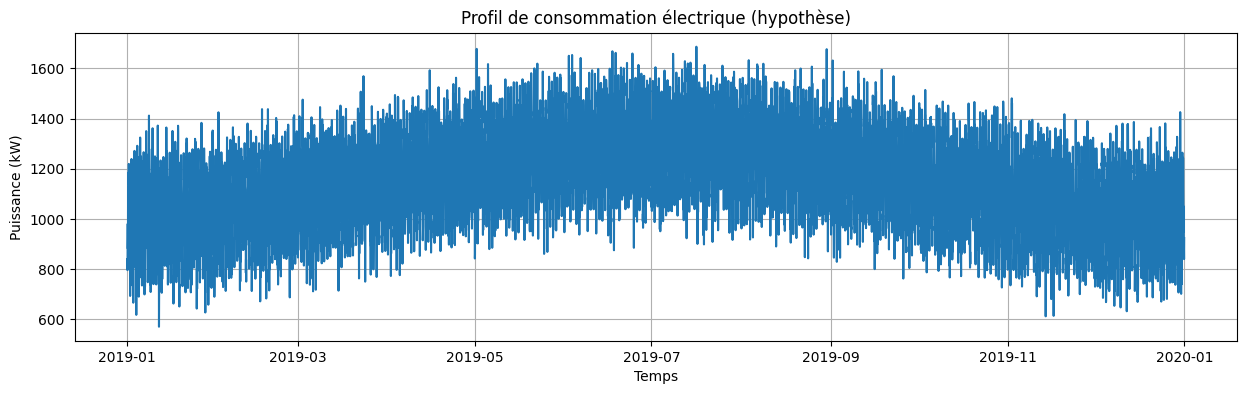

In [16]:
# ===============================
# Création d'une demande synthétique
# ===============================

np.random.seed(42)  # pour avoir toujours le même résultat

hours = 8760

# Base de charge
base_load = 800

# Variation journalière
daily_cycle = 200 * (1 + np.sin(2 * np.pi * np.arange(hours) / 24 - np.pi/2))

# Variation saisonnière
seasonal_cycle = 150 * (1 + np.sin(2 * np.pi * np.arange(hours) / 8760 - np.pi/2))

# Bruit aléatoire
random_variation = np.random.normal(0, 80, hours)

# Demande totale
demand = base_load + daily_cycle + seasonal_cycle + random_variation

# Bornes réalistes
demand = np.clip(demand, 300, 2000)

# DataFrame final
demand_series = pd.DataFrame({
    "time": solar["time"],
    "demand_kw": demand
})

print("Longueur demande :", len(demand_series))
print("Consommation annuelle estimée (MWh) :", demand_series["demand_kw"].sum() / 1000)

plt.figure(figsize=(15,4))
plt.plot(demand_series["time"], demand_series["demand_kw"])
plt.title("Profil de consommation électrique (hypothèse)")
plt.xlabel("Temps")
plt.ylabel("Puissance (kW)")
plt.grid(True)
plt.show()

In [17]:
# ===============================
# Préparation des profils de production
# ===============================

# On suppose que ces colonnes existent déjà :
# solar["solar_cf"], wind["wind_cf"], demand_series["demand_kw"]

# Profil hydrolien provisoire :
# tant qu'on n'a pas reconstruit la vraie série temporelle,
# on le met à zéro pour ne pas inventer de faux résultats.
# Plus tard, on remplacera simplement cette ligne.
hydro_cf = np.zeros(len(solar))

# Vérifications
print("Longueur solaire :", len(solar["solar_cf"]))
print("Longueur éolien  :", len(wind["wind_cf"]))
print("Longueur demande :", len(demand_series["demand_kw"]))
print("Longueur hydro   :", len(hydro_cf))

Longueur solaire : 8760
Longueur éolien  : 8760
Longueur demande : 8760
Longueur hydro   : 8760


In [18]:
# ===============================
# Simulation heure par heure
# ===============================

def simulate_system(pv_kw, wind_kw, hydro_kw, battery_kwh,
                    eta_charge=0.95, eta_discharge=0.95,
                    battery_power_ratio=0.5):
    """
    Simule le système heure par heure.

    battery_power_ratio = puissance max charge/décharge en fraction de la capacité batterie
    ex: 0.5 => une batterie de 4000 kWh peut charger/décharger à 2000 kW max
    """

    demand = demand_series["demand_kw"].values
    solar_prod = solar["solar_cf"].values * pv_kw
    wind_prod  = wind["wind_cf"].values * wind_kw
    hydro_prod = hydro_cf * hydro_kw

    renewable_prod = solar_prod + wind_prod + hydro_prod

    soc = 0.5 * battery_kwh   # état initial à 50%
    soc_list = []
    diesel_list = []
    curtailment_list = []
    battery_charge_list = []
    battery_discharge_list = []

    battery_power_max = battery_kwh * battery_power_ratio

    for t in range(len(demand)):
        prod = renewable_prod[t]
        load = demand[t]
        net = prod - load

        charge = 0
        discharge = 0
        diesel = 0
        curtailment = 0

        if net >= 0:
            # surplus : on charge la batterie
            charge_possible = min(net, battery_power_max)
            energy_to_store = charge_possible * eta_charge
            actual_store = min(energy_to_store, battery_kwh - soc)
            soc += actual_store

            # énergie réellement absorbée côté réseau
            charge = actual_store / eta_charge if eta_charge > 0 else 0

            # surplus restant perdu
            curtailment = net - charge

        else:
            # déficit : on décharge la batterie
            deficit = -net
            discharge_possible = min(deficit, battery_power_max)

            # énergie disponible côté réseau depuis la batterie
            max_deliverable_from_soc = soc * eta_discharge
            actual_discharge = min(discharge_possible, max_deliverable_from_soc)

            # énergie retirée du SOC
            soc_draw = actual_discharge / eta_discharge if eta_discharge > 0 else 0
            soc -= soc_draw

            discharge = actual_discharge

            remaining_deficit = deficit - discharge

            # le diesel couvre le reste
            diesel = max(0, remaining_deficit)

        soc_list.append(soc)
        diesel_list.append(diesel)
        curtailment_list.append(curtailment)
        battery_charge_list.append(charge)
        battery_discharge_list.append(discharge)

    results = {
        "pv_kw": pv_kw,
        "wind_kw": wind_kw,
        "hydro_kw": hydro_kw,
        "battery_kwh": battery_kwh,
        "renewable_prod_kwh": renewable_prod.sum(),
        "diesel_kwh": np.sum(diesel_list),
        "curtailment_kwh": np.sum(curtailment_list),
        "demand_kwh": np.sum(demand),
        "diesel_share": np.sum(diesel_list) / np.sum(demand),
        "renewable_share": 1 - (np.sum(diesel_list) / np.sum(demand)),
        "soc": np.array(soc_list),
        "diesel_ts": np.array(diesel_list),
        "curtailment_ts": np.array(curtailment_list),
        "solar_prod_ts": solar_prod,
        "wind_prod_ts": wind_prod,
        "hydro_prod_ts": hydro_prod,
        "total_renewable_ts": renewable_prod,
        "battery_charge_ts": np.array(battery_charge_list),
        "battery_discharge_ts": np.array(battery_discharge_list),
    }

    return results

In [19]:
# ===============================
# Recherche par grille
# ===============================

# Grille de recherche
pv_range = [0, 1000, 2000, 3000, 4000, 5000]
wind_range = [0, 1000, 2000, 3000, 4000, 5000]
hydro_range = [0]   # provisoire tant qu'on n'a pas la série hydrolienne
battery_range = [0, 2000, 4000, 6000, 8000, 10000]

all_results = []

for pv_kw in pv_range:
    for wind_kw in wind_range:
        for hydro_kw in hydro_range:
            for battery_kwh in battery_range:
                sim = simulate_system(
                    pv_kw=pv_kw,
                    wind_kw=wind_kw,
                    hydro_kw=hydro_kw,
                    battery_kwh=battery_kwh
                )

                # Score : on veut minimiser le diesel
                # mais aussi éviter de surdimensionner trop fort
                oversizing_penalty = (
                    0.00002 * pv_kw +
                    0.00003 * wind_kw +
                    0.00001 * battery_kwh
                )

                score = sim["diesel_share"] + oversizing_penalty

                all_results.append({
                    "pv_kw": pv_kw,
                    "wind_kw": wind_kw,
                    "hydro_kw": hydro_kw,
                    "battery_kwh": battery_kwh,
                    "diesel_kwh": sim["diesel_kwh"],
                    "diesel_share": sim["diesel_share"],
                    "renewable_share": sim["renewable_share"],
                    "curtailment_kwh": sim["curtailment_kwh"],
                    "score": score
                })

results_df = pd.DataFrame(all_results).sort_values("score").reset_index(drop=True)

print("Top 10 des configurations :")
display(results_df.head(10))

Top 10 des configurations :


,pv_kw,wind_kw,hydro_kw,battery_kwh,diesel_kwh,diesel_share,renewable_share,curtailment_kwh,score
0,2000,3000,0,2000,6.449659e+05,0.064025,0.935975,8.593007e+06,0.214025
1,2000,3000,0,0,8.588688e+05,0.085259,0.914741,8.830518e+06,0.215259
2,1000,3000,0,0,1.102771e+06,0.109471,0.890529,7.751039e+06,0.219471
3,1000,3000,0,2000,9.143127e+05,0.090763,0.909237,7.541722e+06,0.220763
4,2000,3000,0,4000,5.168004e+05,0.051302,0.948698,8.449943e+06,0.221302
5,1000,4000,0,0,8.252305e+05,0.081920,0.918080,1.260633e+07,0.221920
6,2000,2000,0,2000,1.033320e+06,0.102577,0.897423,3.840070e+06,0.222577
7,3000,2000,0,4000,6.378050e+05,0.063314,0.936686,4.739026e+06,0.223314
8,2000,4000,0,0,6.437741e+05,0.063907,0.936093,1.374826e+07,0.223907
9,3000,3000,0,2000,5.460196e+05,0.054203,0.945797,9.815131e+06,0.224203


In [20]:
# ===============================
# Meilleure configuration
# ===============================

best = results_df.iloc[0]

best_pv = int(best["pv_kw"])
best_wind = int(best["wind_kw"])
best_hydro = int(best["hydro_kw"])
best_battery = int(best["battery_kwh"])

best_sim = simulate_system(
    pv_kw=best_pv,
    wind_kw=best_wind,
    hydro_kw=best_hydro,
    battery_kwh=best_battery
)

print("Meilleure configuration trouvée :")
print(f"PV installé            : {best_pv} kW")
print(f"Eolien installé        : {best_wind} kW")
print(f"Hydrolien installé     : {best_hydro} kW")
print(f"Batterie installée     : {best_battery} kWh")
print(f"Part diesel            : {100*best_sim['diesel_share']:.2f} %")
print(f"Part renouvelable      : {100*best_sim['renewable_share']:.2f} %")
print(f"Energie diesel         : {best_sim['diesel_kwh']/1000:.2f} MWh")
print(f"Energie écrêtée        : {best_sim['curtailment_kwh']/1000:.2f} MWh")
print(f"Demande annuelle       : {best_sim['demand_kwh']/1000:.2f} MWh")

Meilleure configuration trouvée :
PV installé            : 2000 kW
Eolien installé        : 3000 kW
Hydrolien installé     : 0 kW
Batterie installée     : 2000 kWh
Part diesel            : 6.40 %
Part renouvelable      : 93.60 %
Energie diesel         : 644.97 MWh
Energie écrêtée        : 8593.01 MWh
Demande annuelle       : 10073.61 MWh


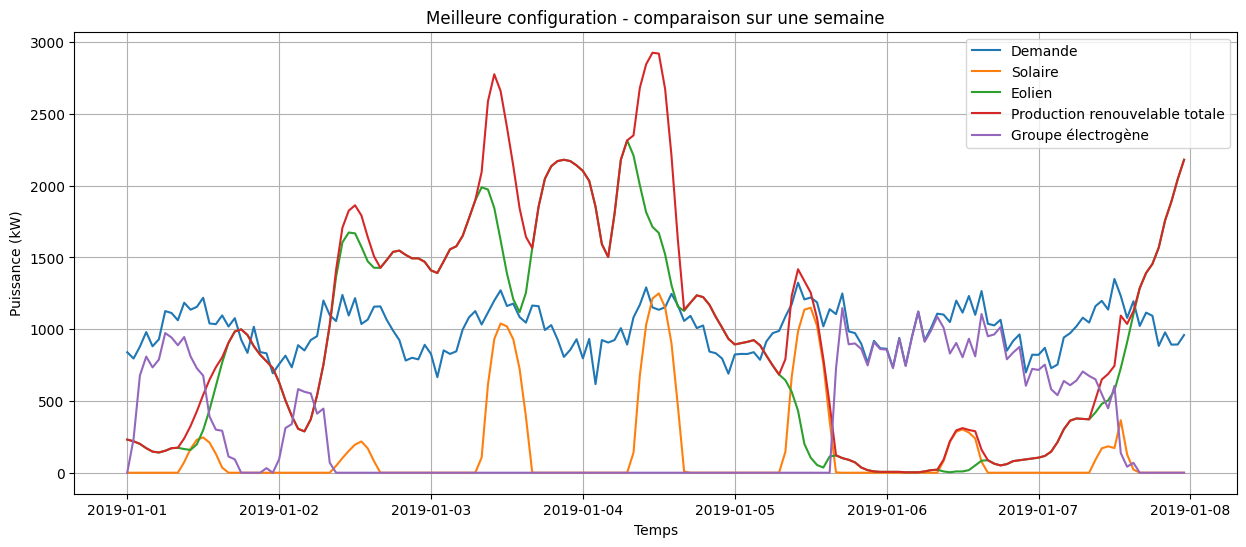

In [21]:
# ===============================
# Visualisation de la meilleure solution
# ===============================

start = 0
end = 24 * 7  # 1 semaine

time_week = solar["time"].iloc[start:end]
demand_week = demand_series["demand_kw"].iloc[start:end]

plt.figure(figsize=(15,6))
plt.plot(time_week, demand_week, label="Demande")
plt.plot(time_week, best_sim["solar_prod_ts"][start:end], label="Solaire")
plt.plot(time_week, best_sim["wind_prod_ts"][start:end], label="Eolien")
plt.plot(time_week, best_sim["total_renewable_ts"][start:end], label="Production renouvelable totale")
plt.plot(time_week, best_sim["diesel_ts"][start:end], label="Groupe électrogène")
plt.title("Meilleure configuration - comparaison sur une semaine")
plt.xlabel("Temps")
plt.ylabel("Puissance (kW)")
plt.legend()
plt.grid(True)
plt.show()

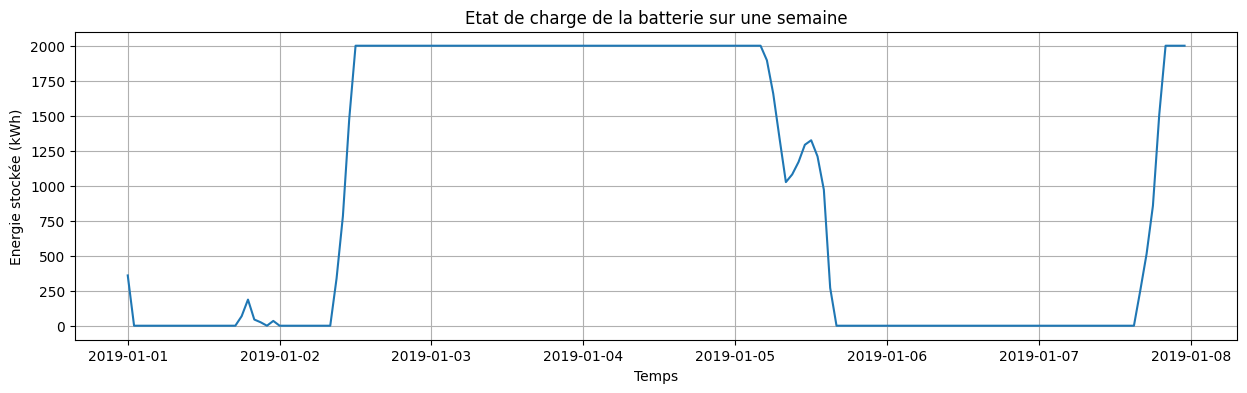

In [22]:
# ===============================
# Etat de charge de la batterie
# ===============================

plt.figure(figsize=(15,4))
plt.plot(time_week, best_sim["soc"][start:end])
plt.title("Etat de charge de la batterie sur une semaine")
plt.xlabel("Temps")
plt.ylabel("Energie stockée (kWh)")
plt.grid(True)
plt.show()

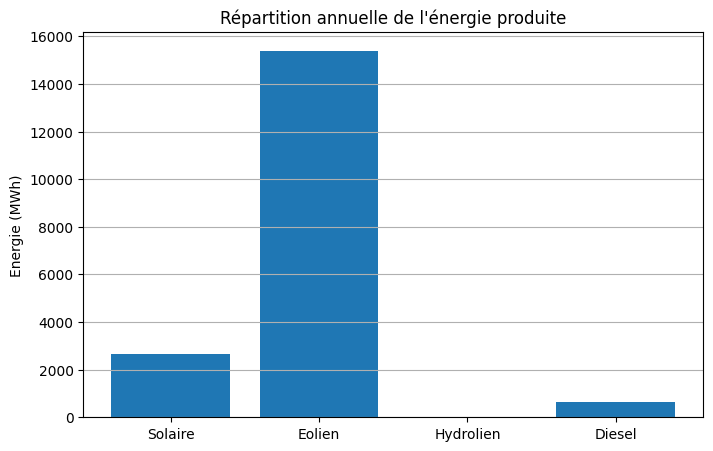

In [23]:
# ===============================
# Répartition énergétique annuelle
# ===============================

annual_solar = best_sim["solar_prod_ts"].sum() / 1000
annual_wind = best_sim["wind_prod_ts"].sum() / 1000
annual_hydro = best_sim["hydro_prod_ts"].sum() / 1000
annual_diesel = best_sim["diesel_kwh"] / 1000

labels = ["Solaire", "Eolien", "Hydrolien", "Diesel"]
values = [annual_solar, annual_wind, annual_hydro, annual_diesel]

plt.figure(figsize=(8,5))
plt.bar(labels, values)
plt.title("Répartition annuelle de l'énergie produite")
plt.ylabel("Energie (MWh)")
plt.grid(True, axis="y")
plt.show()

### Répartition annuelle de l'énergie produite

Ce graphique présente la répartition annuelle de l'énergie produite par les différentes technologies considérées dans la simulation : solaire, éolien, hydrolien et groupe électrogène.

Dans cette configuration, l'éolien représente la principale source de production d'énergie, ce qui s'explique par un facteur de charge généralement plus élevé et plus régulier que celui du solaire. Le solaire contribue également à la production totale, mais sa production reste fortement dépendante de l'alternance jour-nuit et des variations saisonnières.

Le groupe électrogène intervient uniquement pour couvrir les périodes où la production renouvelable et la batterie ne suffisent pas à satisfaire la demande. L'objectif du dimensionnement est précisément de minimiser cette contribution afin de réduire la dépendance aux combustibles fossiles.

La production hydrolienne apparaît nulle dans cette simulation car la série temporelle hydrolienne complète n'a pas encore été intégrée au modèle. Elle sera ajoutée dans les étapes suivantes du projet afin d'évaluer son potentiel réel dans le mix énergétique.

Ce graphique permet ainsi d'avoir une première estimation de la contribution relative des différentes technologies dans le système énergétique étudié et met en évidence le rôle complémentaire des différentes sources renouvelables.

## Conclusion générale

Cette première phase du travail avait pour objectif d'explorer les ressources renouvelables disponibles et d'évaluer leur capacité potentielle à couvrir la demande électrique du système étudié.

L'analyse des séries temporelles solaires et éoliennes montre une forte variabilité de ces ressources, avec une production solaire fortement dépendante du cycle jour-nuit et des saisons, et une production éolienne plus irrégulière mais potentiellement disponible à toute heure.

Une simulation simplifiée du système énergétique a ensuite été réalisée en combinant production renouvelable, stockage batterie et groupe électrogène d'appoint. Cette approche permet d'estimer les ordres de grandeur nécessaires pour limiter l'utilisation du diesel.

Les résultats montrent qu'une combinaison de production solaire, éolienne et stockage peut significativement réduire la part du groupe électrogène dans l'approvisionnement énergétique. Néanmoins, ce dernier reste nécessaire pour assurer la sécurité d'approvisionnement lors des périodes de faible production renouvelable.

Plusieurs améliorations seront apportées dans la suite du projet :
- intégration d'une série temporelle hydrolienne complète
- utilisation de données réelles de consommation horaire
- introduction d'hypothèses technico-économiques plus précises
- optimisation complète du système énergétique à l'aide du modèle GBOML

Cette étape constitue donc une base de travail solide pour la modélisation et l'optimisation futures du système énergétique étudié.